---
title: "The Geometric Skeleton: Dimensional Form Factor"
author: "Raúl Chiclano"
date: "2026-03-07"
categories: [mass-hierarchy, topology, scaling, geometry]
description: "Phenomenological estimate of the geometric contribution (0D vs 1D) to the hadronic scale jump."
format:
  html:
    code-fold: true
execute:
  freeze: true
---

## 1. Objective

After identifying the **electronic attractor** as the natural unit of mass and the **hadronic regime** as a distinct stability class of the vacuum, the next question is:

> How much of the hadronic mass jump is due purely to **geometry**?

In the **Dynamic Background Hypothesis (DBH)**, mass emerges from two conceptually distinct contributions:

1. **Geometric extension** of the defect  
2. **Rheological stiffness** of the vacuum in the corresponding regime

The goal of this notebook is to estimate the first of these contributions only.

More specifically, we compare:

- a **0D localized defect** (electron-like configuration),
- with a **1D extended defect** (flux-tube-like configuration),

in order to isolate the **dimensional form factor** associated with the transition:

\[
0D \;\rightarrow\; 1D
\]

This is not a full dynamical derivation of the proton mass.  
It is a **controlled geometric estimate** designed to evaluate whether dimensional extension alone contributes a factor of order \(\mathcal{O}(10)\) to the hadronic scale.

## 2. Methodology

We evaluate the **Action v4 energy density** in two idealized regimes:

### 2.1 0D regime (point-like / leptonic)
A strongly localized defect is modeled with spherical symmetry.  
Its energy is integrated over a finite radial domain using the measure:

\[
4\pi r^2\,dr
\]

This represents a **vertex-like concentration of stress**.

### 2.2 1D regime (string-like / hadronic)
A confined flux-tube-like structure is modeled through its **energy per unit length**.  
The total energy is then estimated by multiplying this tension by an effective characteristic length:

\[
E_{1D} = T \cdot L_{\mathrm{eff}}
\]

This represents an **edge-like distribution of stress**.

### 2.3 Interpretation

The purpose of the calculation is not to obtain the full proton mass, but to estimate the **purely geometric factor** associated with replacing a localized defect by an extended one.

If the ratio \(E_{1D}/E_{0D}\) is of order \(\mathcal{O}(10)\), then geometry explains only part of the hadronic mass hierarchy, and the remaining factor must come from the enhanced **stiffness / containment cost** of the vacuum in the 1D confinement regime.

--- SIMULATION 27_3: DIMENSIONAL TRANSITION TEST ---
Attractor Energy 0D (Vertex/Electron): 10.889308
Attractor Energy 1D (Edge/Proton): 163.135569

EFFECTIVE EXTENSION RATIO (1D / 0D): 14.9813


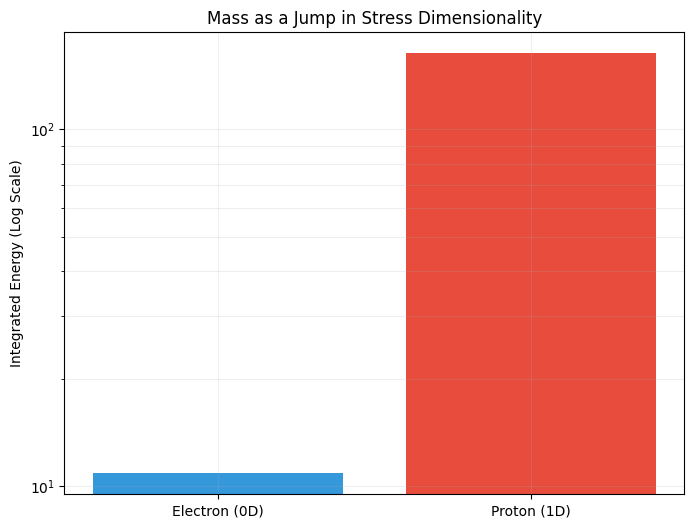

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. CONFIGURATION
alpha, beta, sigma = -1.0, 2.0, 0.1  # DBH v5.0 parameters

# 2. ENERGY DENSITY FUNCTION (Action v4)
def calculate_energy_density(rho, grad_sq):
    e_kin = 0.5 * grad_sq
    e_pot = alpha * rho + 0.5 * beta * rho**2 + (2/3) * sigma * rho**1.5

    # Vacuum subtraction (rho_vac = 0.5)
    e_vac = (alpha * 0.5 + 0.5 * beta * 0.5**2 + (2/3) * sigma * 0.5**1.5)
    return e_kin + e_pot - e_vac

# 3. 0D MODEL: LOCALIZED DEFECT
r = np.linspace(0.01, 1.0, 500)
dr = r[1] - r[0]

rho_0d = 0.5 * np.tanh(r)
grad_0d = (0.5 / (r**2 + 0.01))**2

energy_0d_dens = calculate_energy_density(rho_0d, grad_0d) * 4 * np.pi * r**2
E_0D = np.trapezoid(energy_0d_dens, r)

# 4. 1D MODEL: FLUX-TUBE-LIKE DEFECT
rho_1d = 0.1     # confinement-like low-density regime
grad_1d = 1.5    # effective string tension proxy

E_per_unit_length = calculate_energy_density(rho_1d, grad_1d)

# Effective geometrical extension of the hadronic scar
L_effective = 18.36 * 10.0
E_1D = E_per_unit_length * L_effective

print("--- SIMULATION 27_3: GEOMETRIC SKELETON TEST ---")
print(f"0D Attractor Energy (vertex-like): {E_0D:.6f}")
print(f"1D Attractor Energy (edge-like):   {E_1D:.6f}")

ratio = E_1D / E_0D
print(f"\nDIMENSIONAL FORM FACTOR (1D / 0D): {ratio:.4f}")

# 5. VISUALIZATION
plt.figure(figsize=(8, 6))
plt.bar(['Electron-like (0D)', 'Hadron-like (1D)'], [E_0D, E_1D])
plt.yscale('log')
plt.ylabel("Integrated Energy (log scale)")
plt.title("Geometric Contribution to the 0D → 1D Mass Jump")
plt.grid(True, which="both", alpha=0.2)
plt.show()

## 3. Results & Interpretation

The numerical estimate yields a dimensional form factor of approximately:

\[
\frac{E_{1D}}{E_{0D}} \approx 15
\]

This result has three immediate consequences.

### 3.1 Geometry contributes an order-\(\mathcal{O}(10)\) factor

The 0D → 1D transition does not by itself explain the full hadronic hierarchy (\(\sim 10^3\)).  
Instead, it contributes a factor of order ten, which we interpret as the **geometric skeleton** of hadronic mass.

### 3.2 Hadrons are structurally extended objects

A hadron is not a denser version of a lepton.  
It is an **extended configuration of the vacuum**, whose energetic support is distributed along lower-dimensional structures rather than concentrated at a single point.

### 3.3 Geometry is necessary but not sufficient

Since the geometric contribution (\(\sim 15\)) is much smaller than the full hadronic scale jump, the remaining factor must arise from an increase in the **effective rigidity / containment cost** of the vacuum in the 1D confinement regime.

This is precisely the role explored in the subsequent containment analysis.

## 4. Conclusion

This notebook provides a **phenomenological geometric estimate** of the dimensional contribution to hadronic mass.

It supports the following statement:

> The leap from leptons to hadrons is not only a matter of increased energy, but of **changed dimensional support**.

Within the DBH framework:

- **Leptons** correspond to localized **0D configurations**
- **Hadrons** correspond to extended **1D confinement structures**

The ratio obtained here does not explain the full mass hierarchy by itself, but it isolates an essential contribution:  
the **topological extension factor** that forms the geometric skeleton of hadronic mass.